# 103 - Neural Style Transfer

**Section:** Style Transfer | **Prereqs:** `Transfer Learning/TF_VGG-16.ipynb`, `CNNs/Examining_Feature_Maps.ipynb` | **Next:** `Style Transfer/Style_transfer_with _AlexNet.ipynb`

The most conceptually surprising notebook in this course: **the image is the
parameter.** The network is frozen; gradient descent optimises the pixels.

```python
target.requires_grad_(True)                    # the IMAGE is trainable
optimizer = torch.optim.RMSprop([target])      # the optimizer gets pixels
```

Everywhere else in this course the model learns and the data is fixed. Here it is
exactly reversed - and nothing about autograd changes. Anything with
`requires_grad=True` gets a gradient.

**How content and style are separated**
- **Content loss** - MSE between the target's and the content image's feature maps
  at a chosen layer. Feature maps preserve *where* things are, so matching them
  preserves layout.
- **Style loss** - MSE between **Gram matrices** of the target's and the style
  image's feature maps. A Gram matrix is every pairwise dot product between
  channels, summed over all positions - so it records which features co-occur
  and throws away where they occur. That is style: texture and colour
  relationships without layout.

**Which layers to use.** Style from several layers at once (early ones give fine
texture, later ones larger motifs), content from one middle layer - early layers
are too literal, late ones too abstract.

**The one knob that matters:** `style_scaling`. The two losses are on completely
different scales, so this weight decides the balance. Too high and the content
dissolves; too low and nothing happens. Expect to tune it per image pair.

**Why it works at all:** a network trained to classify ImageNet learned a
representation in which content and style are separable. Nobody designed that -
it fell out of the classification objective, which is why this result was
surprising when Gatys et al. published it in 2015.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import torchvision
import torchvision.transforms as T
import torchsummary

import imageio as iio


## Step 1 : Import a pre-trained model

In [52]:
# VGG-19 with ImageNet weights. VGG is the standard choice for style transfer -
# its plain stack of convolutions gives clean, well-separated feature maps at
# every depth. ResNet's skip connections make its features less interpretable
# for this purpose.
vgg_net = torchvision.models.vgg19(weights=torchvision.models.VGG19_Weights.DEFAULT)
vgg_net

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [53]:
# Freeze every parameter. The network is a fixed feature extractor; nothing in
# it will be trained.
# Now we freeze all the layers

for params in vgg_net.parameters():
  params.requires_grad_(False)

In [54]:
# Verify the freeze - important here, since a trainable network would drift
# instead of holding still while the image changes.
isFrozen = True

for params in vgg_net.parameters():
  if params.requires_grad:
    isFrozen = False

if isFrozen == True:
  print('All layers are frozen')
else:
  print("Check all layers are not frozen !!")

All layers are frozen


In [55]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
device

'cuda'

In [56]:
# .eval() disables dropout and switches batch norm to running statistics.
# VGG uses dropout in its classifier, so this matters even though only the
# convolutional part is used.
vgg_net.eval() # Stop gradients .eval() uses running stats for BN, turn off dropout
vgg_net.to(device);

## Step 2 : Import 2 images.

In [89]:
# Two inputs: the content image (what it should depict) and the style image
# (how it should look).
img_content = iio.v3.imread("/content/baymax.jpg")
img_style = iio.v3.imread("/content/images.jpeg")

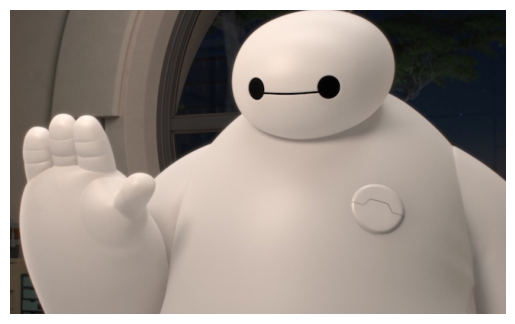

In [90]:
plt.imshow(img_content)
plt.axis('off');

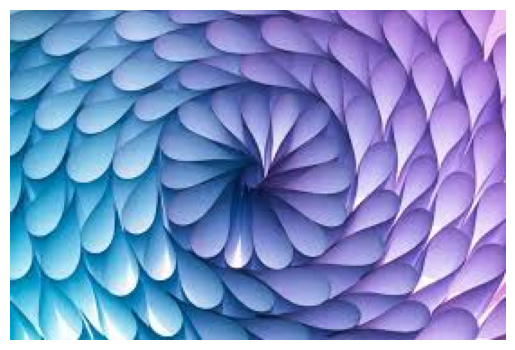

In [91]:
plt.imshow(img_style)
plt.axis('off');

In [92]:
# The target starts as RANDOM NOISE the same size as the content image.
# This is the tensor that will be optimised into the final artwork.
# Starting from a copy of the content image instead converges faster and stays
# closer to the original - the choice the AlexNet notebook makes.
img_target = np.random.randint(low=0, high=225, size=img_content.shape,dtype=np.uint8) # Initializing a random noise image of the same size and the content image.

In [93]:
print(img_content.shape)
print(img_target.shape)
print(img_style.shape)


(399, 650, 3)
(399, 650, 3)
(183, 275, 3)


In [94]:
# ImageNet normalisation, required by the pretrained weights.
# .unsqueeze(0) adds the batch axis: a single image still has to be a batch of one.
transforms = T.Compose([
    T.ToTensor(),
    T.Resize(256),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

img_content = transforms(img_content).unsqueeze(0).to(device) # Unsqueeze to make it 4d because we have no batch.
img_target = transforms(img_target).unsqueeze(0).to(device)
img_style = transforms(img_style).unsqueeze(0).to(device)



In [95]:
print(img_content.shape) # Shape [bs=1, 3, 256, 347]
print(img_target.shape)
print(img_style.shape)


torch.Size([1, 3, 256, 417])
torch.Size([1, 3, 256, 417])
torch.Size([1, 3, 256, 384])


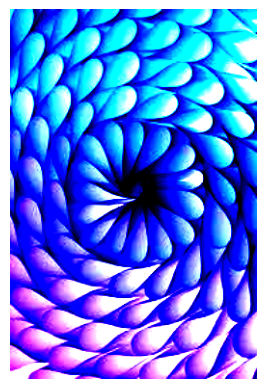

In [96]:
plt.imshow(img_style.cpu().squeeze().permute(2,1,0).numpy());
plt.axis('off');

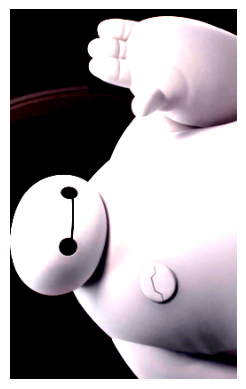

In [97]:
plt.imshow(img_content.cpu().squeeze().permute(2,1,0).numpy());
plt.axis('off');

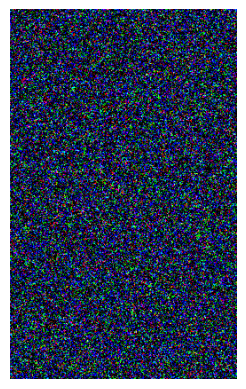

In [98]:
plt.imshow(img_target.cpu().squeeze().permute(2,1,0).numpy());
plt.axis('off');

# Functions to compute and extract feature maps

In [99]:
# Run an image through the network layer by layer and collect the output of every
# convolution.
# Note the loop applies layers one at a time rather than calling net(img) - that
# is the point, since the intermediate activations are what style transfer needs.
# (A forward hook, layer.register_forward_hook, is the general-purpose way to do
# this without stepping through manually.)
def get_feature_maps(img,net):

  feature_maps = []
  feature_names = []

  conv_layerIdx = 0

  for layernum in range(len(net.features)): # Vgg net has 2 blocks , vgg_net.features, vgg_net.classifier

    #print(f"Number : {layernum} | Layer Name : {net.features[layernum] }")

    img = net.features[layernum](img) # Process through a certain layer

    if 'Conv2d' in str(net.features[layernum]): #Checking for Conv layer:

      feature_maps.append(img)
      feature_names.append("ConvLayer_" + str(conv_layerIdx))
      conv_layerIdx += 1

  return feature_maps, feature_names

In [100]:
# The GRAM MATRIX - the whole idea of style transfer in one function.
# Flatten each channel to a vector, then compute every pairwise dot product:
# G[i,j] = how much channel i and channel j fire together, summed over all
# positions.
# Because it sums over position, it discards WHERE anything is and keeps only
# which features co-occur. That is a workable definition of 'style': texture,
# colour relationships and brush character, independent of layout.
# The division by (channels*h*w) normalises for image size.
def gram_matrix(M):

  _, chans, h,w = M.shape

  M = M.reshape(chans, h*w)

  gm = torch.mm(M, M.t()) / (chans * h * w)

  return gm

In [101]:
# Testing the functions

test_fm, test_fn = get_feature_maps(img_content,vgg_net)

In [102]:
# The feature map shapes at each depth: channels grow, resolution shrinks - the
# standard CNN progression.
for i in range(len(test_fm)):
  print(f"{test_fn[i]} | {test_fm[i].shape}")

ConvLayer_0 | torch.Size([1, 64, 256, 417])
ConvLayer_1 | torch.Size([1, 64, 256, 417])
ConvLayer_2 | torch.Size([1, 128, 128, 208])
ConvLayer_3 | torch.Size([1, 128, 128, 208])
ConvLayer_4 | torch.Size([1, 256, 64, 104])
ConvLayer_5 | torch.Size([1, 256, 64, 104])
ConvLayer_6 | torch.Size([1, 256, 64, 104])
ConvLayer_7 | torch.Size([1, 256, 64, 104])
ConvLayer_8 | torch.Size([1, 512, 32, 52])
ConvLayer_9 | torch.Size([1, 512, 32, 52])
ConvLayer_10 | torch.Size([1, 512, 32, 52])
ConvLayer_11 | torch.Size([1, 512, 32, 52])
ConvLayer_12 | torch.Size([1, 512, 16, 26])
ConvLayer_13 | torch.Size([1, 512, 16, 26])
ConvLayer_14 | torch.Size([1, 512, 16, 26])
ConvLayer_15 | torch.Size([1, 512, 16, 26])


In [103]:
gm = gram_matrix(test_fm[0])
gm.shape, test_fm[0].shape

(torch.Size([64, 64]), torch.Size([1, 64, 256, 417]))

# Invesitgating Feature maps

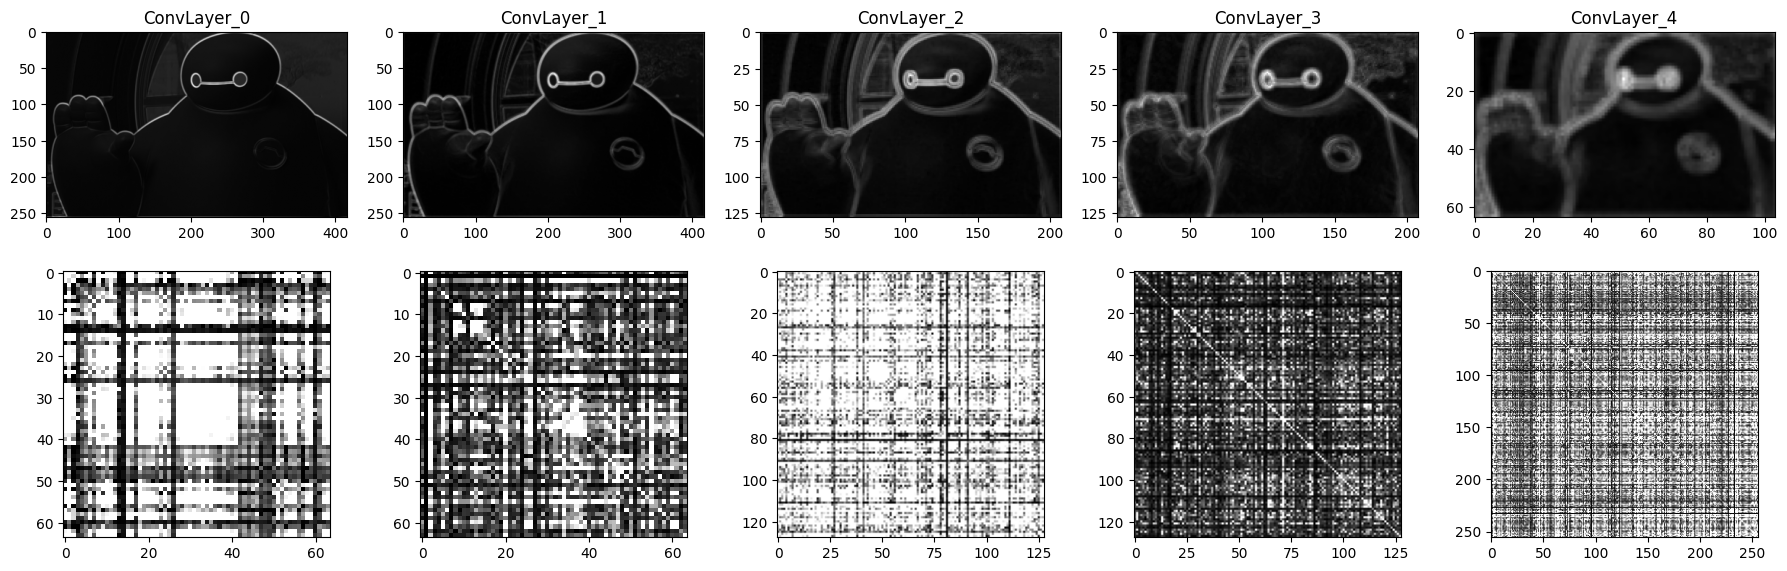

In [104]:
# Feature maps (top) and Gram matrices (bottom) for the CONTENT image.
# The feature maps still look like the picture; the Gram matrices are abstract
# channel-correlation patterns with no spatial layout left. That difference is
# the content/style split, made visible.
fig, ax = plt.subplots(2,5, figsize=(18,6))

for i in range(5):

  pic = np.mean(test_fm[i].cpu().numpy().squeeze(),axis=0)
  pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic)) # Scaling from [0,1]
  ax[0,i].imshow(pic,cmap='grey')
  # ax[0,i].axis('off')
  ax[0,i].set_title(str(test_fn[i]))

  pic = gram_matrix(test_fm[i]).cpu().numpy()
  pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
  ax[1,i].imshow(pic, cmap='gray',vmax=.1)
  # ax[1,i].axis('off')

plt.tight_layout()



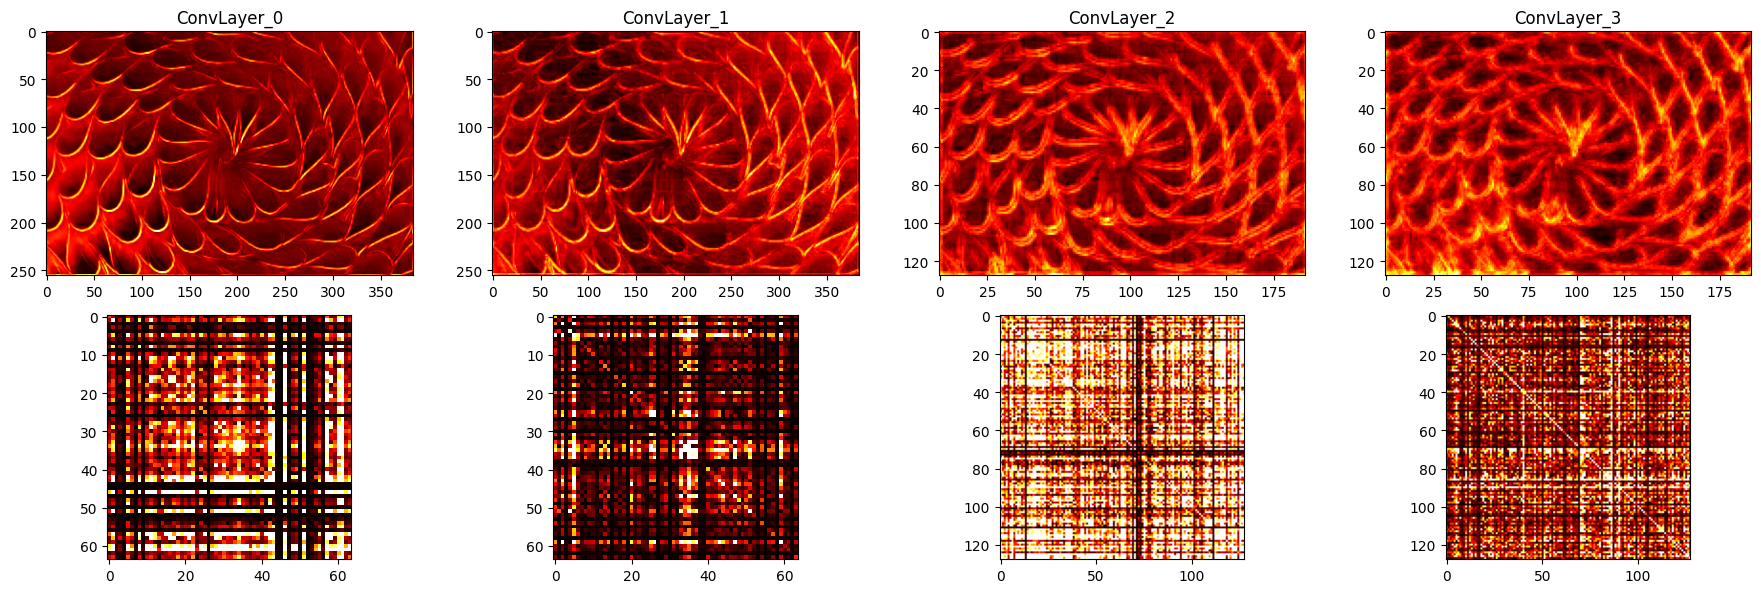

In [105]:
# The same for the STYLE image. Compare the Gram matrices with the content
# image's - these are what the optimisation will match.
test_fm, test_fn = get_feature_maps(img_style,vgg_net)
fig, ax = plt.subplots(2,4, figsize=(18,6))

for i in range(4):

  pic = np.mean(test_fm[i].cpu().numpy().squeeze(),axis=0)
  pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic)) # Scaling from [0,1]
  ax[0,i].imshow(pic,cmap='hot')
  # ax[0,i].axis('off')
  ax[0,i].set_title(str(test_fn[i]))

  pic = gram_matrix(test_fm[i]).cpu().numpy()
  pic = (pic - np.min(pic)) / (np.max(pic) - np.min(pic))
  ax[1,i].imshow(pic, cmap='hot',vmax=.1)
  # ax[1,i].axis('off')

plt.tight_layout()

# Style transfer process

In [106]:
# The layer choices, and the main creative decision in style transfer:
#   content from ONE middle layer - early layers are too literal (pixels), late
#     ones too abstract (object identity),
#   style from SEVERAL layers, weighted - early layers give fine texture, later
#     ones larger motifs.
layers_content = ['ConvLayer_2']
layers_style = ['ConvLayer_0', 'ConvLayer_2', 'ConvLayer_3', 'ConvLayer_4']
weights_style = [1, 0.75, 0.5, 0.25]   # one weight per entry in layers_style

In [116]:
# THE OPTIMISATION. The line that matters is target.requires_grad_(True) and
# passing [target] to the optimizer - the IMAGE is the parameter.
#
# Each step:
#   1. extract feature maps from target, content and style,
#   2. content_loss = MSE between target and content feature maps,
#   3. style_loss   = weighted MSE between their Gram matrices,
#   4. combined = style_scaling*style + content, then backprop into the PIXELS.
#
# style_scaling (5e4) is the one knob that matters: the two losses live on
# completely different scales, and this weight sets the balance. Too high and the
# content dissolves; too low and the style never appears.
#
# The content and style feature maps are computed ONCE, before the loop, under
# torch.no_grad(): those two images never change, so recomputing their features
# 1500 times is pure waste - hoisting them is roughly a 3x speedup.
target = img_target.clone()
target.requires_grad_(True)
target = target.to(device)

content = img_content.clone().to(device)
content.requires_grad_(False) # Content image is fixed, no gradients needed

style_scaling = 5e4 # Scaling up loss function for style. Larger the style_scaling larger the impact of style.

epochs = 1500

optimizer = torch.optim.RMSprop([target],lr=5e-3) # Only target image

# Static targets: computed once, since neither image changes during optimisation.
with torch.no_grad():
  content_feature_maps, _ = get_feature_maps(content, vgg_net)
  style_feature_maps, _   = get_feature_maps(img_style, vgg_net)


for epoch in range(epochs):

  target_feature_maps, target_features_names = get_feature_maps(target, vgg_net)

  style_loss = 0
  content_loss = 0

  for layeri in range(len(target_features_names)):

    # Calculating content loss (no gram matrix , target - content)
    if target_features_names[layeri] in layers_content:
      content_loss += torch.mean( (target_feature_maps[layeri] - content_feature_maps[layeri]) **2) # Calculating MSE

    # Calculating style loss (gram matrix , target - style)
    if target_features_names[layeri] in layers_style:

      GMtarget = gram_matrix(target_feature_maps[layeri])
      GMstyle = gram_matrix(style_feature_maps[layeri])

      style_loss += torch.mean( (GMtarget - GMstyle)**2 ) * weights_style[layers_style.index(target_features_names[layeri])]

  combined_loss = style_scaling*style_loss + content_loss

  optimizer.zero_grad()
  combined_loss.backward()
  optimizer.step()

## Results !!

In [117]:
# Denormalisation for display: the inverse of the ImageNet Normalize.
# The mean/std arithmetic here is the standard way to invert it.
def imshow(img, ax, title=None):
    # Denormalize the image
    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img = inv_normalize(img)

    # Convert to numpy and transpose for matplotlib
    npimg = img.cpu().detach().numpy().squeeze().transpose((1, 2, 0))

    # Clip values to [0, 1] as imshow expects this range for float images
    npimg = np.clip(npimg, 0, 1)

    ax.imshow(npimg)
    ax.axis('off')
    if title:
        ax.set_title(title)

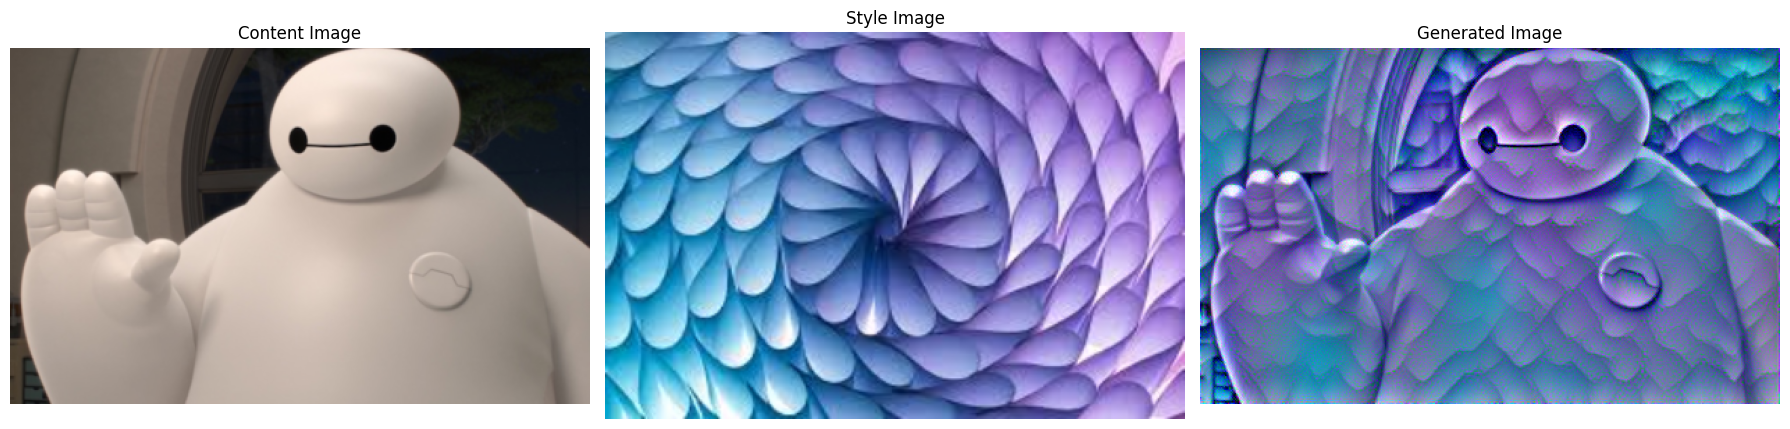

In [118]:
# Content, style and result side by side.
# What to look for: the layout of the content image with the texture and palette
# of the style image. If the content has dissolved, lower style_scaling; if the
# style is invisible, raise it.
fig, ax = plt.subplots(1,3, figsize=(18,11))

# Plot content image
imshow(img_content, ax[0], title='Content Image')

# Plot style image
imshow(img_style, ax[1], title='Style Image')

# Plot target (generated) image
imshow(target, ax[2], title='Generated Image')

plt.tight_layout()
plt.show()